# 03 — Privacy, GDPR, and AI Act Governance
**Role:** Governance Officer  
**Goal:** Identify PII, demonstrate pseudonymization/anonymization, and propose governance controls aligned with GDPR and EU AI Act.

## Purpose
This notebook analyzes NovaCred credit application data through a privacy, governance, and regulatory lens. It identifies PII fields, demonstrates pseudonymization/minimization, maps findings to GDPR requirements (including automated decision-making), references the EU AI Act high-risk classification, and proposes concrete governance controls.

## Dataset
- **Source:** `../raw_credit_applications.json` (nested JSON)
- **Derived output:** `../data/processed/applications_privacy_safe.csv` (pseudonymized + minimized)
- **Context:** synthetic credit application records from the NovaCred fintech platform

In [1]:
import json
import pandas as pd
from pathlib import Path

# Adjust if your filename is different
data_path = Path("../raw_credit_applications.json")

with open(data_path, "r", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df.shape, df.columns

((502, 8),
 Index(['_id', 'applicant_info', 'financials', 'spending_behavior', 'decision',
        'processing_timestamp', 'loan_purpose', 'notes'],
       dtype='object'))

In [2]:
pii_candidates = ["full_name", "email", "ssn", "ip_address", "date_of_birth", "zip_code"]
present_pii = [c for c in pii_candidates if c in df.columns]

present_pii

[]

In [3]:
import pandas as pd

# Flatten nested JSON keys into columns (applicant_info.email, etc.)
df_flat = pd.json_normalize(raw)

df_flat.shape, df_flat.columns.tolist()[:30]

((502, 21),
 ['_id',
  'spending_behavior',
  'processing_timestamp',
  'applicant_info.full_name',
  'applicant_info.email',
  'applicant_info.ssn',
  'applicant_info.ip_address',
  'applicant_info.gender',
  'applicant_info.date_of_birth',
  'applicant_info.zip_code',
  'financials.annual_income',
  'financials.credit_history_months',
  'financials.debt_to_income',
  'financials.savings_balance',
  'decision.loan_approved',
  'decision.rejection_reason',
  'loan_purpose',
  'decision.interest_rate',
  'decision.approved_amount',
  'financials.annual_salary',
  'notes'])

In [4]:
# Show columns that contain likely PII words
pii_keywords = ["name", "email", "ssn", "ip", "birth", "dob", "zip", "address", "phone"]
[c for c in df_flat.columns if any(k in c.lower() for k in pii_keywords)]

['applicant_info.full_name',
 'applicant_info.email',
 'applicant_info.ssn',
 'applicant_info.ip_address',
 'applicant_info.date_of_birth',
 'applicant_info.zip_code']

In [5]:
pii_candidates = [
    "applicant_info.full_name",
    "applicant_info.email",
    "applicant_info.ssn",
    "applicant_info.ip_address",
    "applicant_info.date_of_birth",
    "applicant_info.zip_code"
]

present_pii = [c for c in pii_candidates if c in df_flat.columns]
present_pii

['applicant_info.full_name',
 'applicant_info.email',
 'applicant_info.ssn',
 'applicant_info.ip_address',
 'applicant_info.date_of_birth',
 'applicant_info.zip_code']

In [6]:
pii_stats = []
for col in present_pii:
    series = df_flat[col]
    blanks = series.astype(str).str.strip().eq("").sum()
    missing = series.isna().sum() + blanks

    pii_stats.append({
        "field": col,
        "missing_count": int(missing),
        "missing_pct": round(100 * missing / len(df_flat), 2)
    })

pii_report = pd.DataFrame(pii_stats).sort_values("missing_pct", ascending=False)
pii_report

,field,missing_count,missing_pct
1,applicant_info.email,7,1.39
2,applicant_info.ssn,5,1.00
4,applicant_info.date_of_birth,5,1.00
3,applicant_info.ip_address,5,1.00
5,applicant_info.zip_code,2,0.40
0,applicant_info.full_name,0,0.00


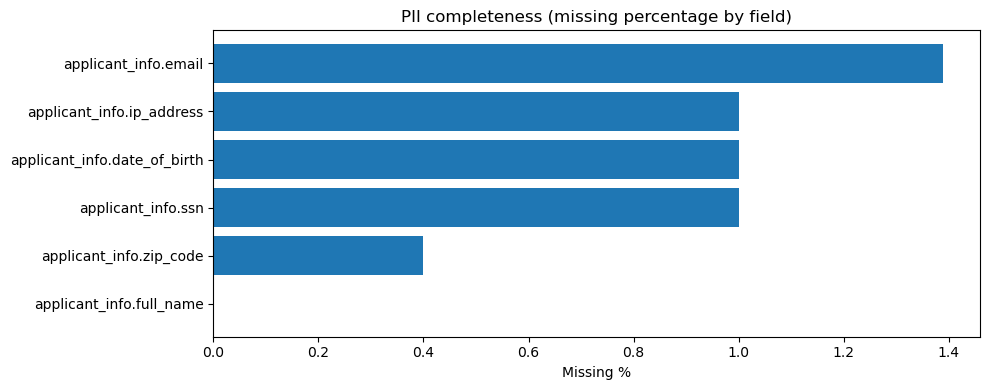

In [7]:
import matplotlib.pyplot as plt

plot_df = pii_report.sort_values("missing_pct", ascending=True)

plt.figure(figsize=(10, 4))
plt.barh(plot_df["field"], plot_df["missing_pct"])
plt.xlabel("Missing %")
plt.title("PII completeness (missing percentage by field)")
plt.tight_layout()
plt.show()

## 1) PII identification (dataset evidence)

We identify personal data fields and quantify completeness to support governance and compliance controls.

PII categories used in this notebook
- **Direct identifiers:** uniquely identify a person (e.g., full name, SSN, email, IP).
- **Quasi-identifiers:** identify a person when combined (e.g., ZIP + DOB).
- **Sensitive behavioral data:** reveals patterns that may infer sensitive traits (e.g., `spending_behavior`).

1.1 — Pseudonymize Email + SSN (HASH) and drop raw values

In [8]:
import hashlib
import pandas as pd

df_priv = df_flat.copy()

def sha256_hash(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == "":
        return None
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

# Hash email + SSN (pseudonymization)
df_priv["applicant_info.email_hash"] = df_priv["applicant_info.email"].apply(sha256_hash)
df_priv["applicant_info.ssn_hash"] = df_priv["applicant_info.ssn"].apply(sha256_hash)

# Remove raw direct identifiers from the analytics dataset
df_priv = df_priv.drop(columns=["applicant_info.email", "applicant_info.ssn"])

df_priv[["applicant_info.email_hash", "applicant_info.ssn_hash"]].head()



,applicant_info.email_hash,applicant_info.ssn_hash
0,116648a7761525746032d0ab323ceb01f50d11f7935164...,2caf30528c21a10e1307b27f9dbbfc312f0c00d46b333e...
1,c3522c0b54ef9045c73186bcabb53f8e512360ed17e9cc...,2f7da45fefdcfb2c5b4f5b6f1465c22054c36e04fc77c1...
2,b299e7d6a37e183bab209eb8df919652117dd16ed16698...,db120edcee2366a48d6d77c2db8c64c5536b8dc3c3c524...
3,6fbd2478748a29faa143392f28d955133e346d09673963...,c835719be02018987096d6e49529a24b1d7e7ab35c84b1...
4,f24e7cc1450ee9aa26b833e0593b2420fbfd59b8ad2636...,41c7de40dc49185886e6ecb37346ec9eabce16087b7508...


1.2 Mask IP address and drop raw IP

In [9]:
def mask_ip(ip):
    if pd.isna(ip):
        return None
    s = str(ip).strip()
    if s == "":
        return None
    parts = s.split(".")
    if len(parts) == 4:
        return ".".join(parts[:3]) + ".0"
    return None

df_priv["applicant_info.ip_masked"] = df_flat["applicant_info.ip_address"].apply(mask_ip)

# Drop raw IP
df_priv = df_priv.drop(columns=["applicant_info.ip_address"])

df_priv[["applicant_info.ip_masked"]].head()

,applicant_info.ip_masked
0,192.168.48.0
1,10.1.102.0
2,10.240.193.0
3,192.168.175.0
4,172.29.125.0


Pseudonymization vs anonymization
Hashing SSN/email is **pseudonymization**, not anonymization. If someone has the original value, they can hash it and match it to the dataset. GDPR **Art. 4(5)** recognizes pseudonymization as a risk-reduction measure, but it remains personal data and still requires GDPR controls.

1.3 Convert DOB to age bands and drop exact DOB

In [10]:
from datetime import datetime

def parse_dob(d):
    if pd.isna(d):
        return None
    s = str(d).strip()
    if s == "":
        return None
    fmts = ["%Y-%m-%d", "%d/%m/%Y", "%m/%d/%Y", "%Y/%m/%d"]
    for fmt in fmts:
        try:
            return datetime.strptime(s, fmt).date()
        except:
            continue
    return None

def age_band(dob_date):
    if dob_date is None:
        return None
    today = datetime.today().date()
    age = (today - dob_date).days // 365
    if age < 18: return "<18"
    if age <= 25: return "18-25"
    if age <= 35: return "26-35"
    if age <= 45: return "36-45"
    if age <= 60: return "46-60"
    return "60+"

dob_parsed = df_flat["applicant_info.date_of_birth"].apply(parse_dob)
df_priv["applicant_info.age_band"] = dob_parsed.apply(age_band)

# Drop exact DOB
df_priv = df_priv.drop(columns=["applicant_info.date_of_birth"])

df_priv["applicant_info.age_band"].value_counts(dropna=False)

applicant_info.age_band
36-45    170
26-35    158
46-60    108
60+       39
18-25     22
None       5
Name: count, dtype: int64

In [11]:
if "applicant_info.full_name" in df_priv.columns:
    df_priv = df_priv.drop(columns=["applicant_info.full_name"])

df_priv.columns
#I removed direct identification

Index(['_id', 'spending_behavior', 'processing_timestamp',
       'applicant_info.gender', 'applicant_info.zip_code',
       'financials.annual_income', 'financials.credit_history_months',
       'financials.debt_to_income', 'financials.savings_balance',
       'decision.loan_approved', 'decision.rejection_reason', 'loan_purpose',
       'decision.interest_rate', 'decision.approved_amount',
       'financials.annual_salary', 'notes', 'applicant_info.email_hash',
       'applicant_info.ssn_hash', 'applicant_info.ip_masked',
       'applicant_info.age_band'],
      dtype='object')

1.4 GDPR mapping

## 2) GDPR principles → applied controls

- **Purpose limitation:** PII is used only for operational identity checks; analytics uses pseudonymized fields.
- **Data minimization:** Removed raw SSN/email and full name; DOB converted to age band; IP masked.
- **Accuracy:** Missing/invalid PII is detectable via data quality checks and remediation workflow.
- **Storage limitation:** Define a retention period and deletion workflow for applications and derived datasets.
- **Integrity & confidentiality:** RBAC + encryption + access logging for PII and decision data.
- **Accountability:** Controls Matrix documents ownership, frequency, and artifacts for audit readiness.

## 3) EU AI Act governance implications

Credit decision systems are treated as **high-risk AI** → governance expectations include:
- Data governance and quality management
- Logging and technical documentation
- Transparency to affected individuals
- Human oversight for sensitive decisions
- Ongoing monitoring (including bias/proxy checks) and risk management

step 3.1 Save a privacy-safe dataset

In [12]:
from pathlib import Path

out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

out_file = out_dir / "applications_privacy_safe.csv"
df_priv.to_csv(out_file, index=False)

out_file

WindowsPath('../data/processed/applications_privacy_safe.csv')

## 4) GDPR Articles Mapping (what this notebook implements)

The table below maps concrete actions and findings from this notebook to key GDPR provisions.  
Where the dataset does not include required governance metadata (e.g., consent tracking, retention), we flag it as a compliance gap.

| GDPR Article | Requirement (plain English) | What we implemented / observed in NovaCred |
|---|---|---|
| **Art. 5(1)(a) — Lawfulness, fairness, transparency** | Processing must be lawful and transparent to individuals. | We highlight that the dataset does not store explicit lawful basis or consent evidence. This should be tracked and disclosed in a real system. |
| **Art. 6 — Lawful basis** | Processing must have a valid legal basis (e.g., contract necessity, legitimate interest, consent). | Credit processing typically relies on **contract necessity** or **legitimate interest**, but the dataset has **no field** proving what basis was used → governance gap to address. |
| **Art. 13–14 — Transparency notices** | Individuals must be informed about data use, automated decisioning, and their rights. | We recommend including a transparency notice + logging what notice/version was shown at application time (not present in dataset). |
| **Art. 4(5) — Pseudonymization** | GDPR recognizes pseudonymization as a risk-reduction technique (still personal data). | Demonstrated via **SHA-256 hashing** of direct identifiers (SSN/email) and removal of raw values from the analytics dataset. |
| **Art. 5(1)(c) — Data minimization** | Collect/use only what is necessary for the purpose. | We removed raw direct identifiers from the analytics view, masked IP, and converted DOB to age bands to reduce identifiability. |
| **Art. 5(1)(d) — Accuracy** | Personal data must be accurate; errors should be detectable and correctable. | We created a **PII completeness report** (missingness counts/%) to support data quality checks and remediation. |
| **Art. 5(1)(e) — Storage limitation** | Do not keep personal data longer than needed; define retention. | Dataset lacks `retention_until` / deletion metadata. We recommend a retention schedule + deletion workflow and storing `retention_until` per record. |
| **Art. 17 — Right to erasure** | Individuals can request deletion of their data. | We recommend an erasure workflow: locate records via application ID (and/or secure mapping), delete from PII store + derived datasets, and log completion. |
| **Art. 30 — Records of processing activities (RoPA)** | Organizations should document processing purposes, categories, retention, security measures, etc. | Our `docs/governance_framework.md` + `docs/pii_inventory.md` act as project-level documentation; production systems should maintain an official RoPA. |
| **Art. 32 — Security of processing** | Implement appropriate security controls (access control, encryption, logging). | We propose RBAC + encryption + access logging. We also reduce exposure by using a privacy-safe analytics dataset. |
| **Art. 5(2) — Accountability** | Organization must be able to demonstrate compliance. | `docs/controls_matrix.md` defines controls, owners, frequency, and evidence artifacts for audit readiness. |
| **Art. 22 — Automated decision-making** | Individuals have protections when decisions are made solely by automated processing with significant effects. | Credit approval/rejection is a significant decision. The dataset provides outcomes but does not demonstrate safeguards (human review option, consent where needed, explanations) → compliance gap. |

---

### GDPR Art. 22

Credit decisions can have **significant legal and financial effects**. Under **Art. 22**, NovaCred must implement safeguards such as:
- **Transparency** that automated decisioning is being used
- **Human review / appeal mechanism** for borderline or contested decisions
- **Decision logging** (model version, reason codes, reviewer ID + timestamp)
- **Consent or documented lawful basis**, depending on the legal justification used

**Compliance gap identified:** the dataset contains **no field** tracking whether consent was collected for automated decision-making and no audit-trail metadata proving safeguards were applied. This must be addressed before deployment.

---

### Note: pseudonymization is not anonymization

Hashing identifiers is **pseudonymization**, not full anonymization.  
If someone already knows the original value, they can hash it and match it to the dataset. Therefore, the data remains within GDPR scope and still requires security, retention, and accountability controls.

## 5) Governance gaps found in the provided dataset (and what NovaCred should add)

Observed gaps (dataset-level):
- No explicit **consent_timestamp** or lawful basis tracking (who consented, when, and for what purpose).
- No **processing_purpose** metadata to prove purpose limitation.
- No **retention_until** / deletion metadata to enforce storage limitation.
- No formal **audit trail** fields (who accessed data, who/what made the decision, model version, reason codes).
- Sensitive “spending behavior” categories exist without documented purpose/retention controls.

Recommended metadata fields to add:
- consent_timestamp, processing_purpose, data_source, retention_until
- decision_log_id, model_version, decision_reason_codes, human_reviewer_id, review_timestamp

## 6) Proposed governance controls

### Audit trail
Log every decision with timestamp, model version, input features (or feature set ID), outcome, and reason codes.

### Human oversight
Flag borderline cases for manual review and store reviewer ID + review timestamp.

### Consent & transparency
Store `consent_timestamp` and provide clear notice that automated decisioning is being used.

### Retention policy
Define a maximum retention period (e.g., 5 years) and enforce deletion/anonymization afterward.

## 7) Summary

| Area | Status | Gap identified |
|---|---|---|
| PII identification | Done | `spending_behavior` needs purpose justification |
| Pseudonymization/minimization | Done | Raw identifiers must never be shared in analytics outputs |
| GDPR compliance | Partial | No consent tracking, no retention policy, no Art. 22 safeguards demonstrated |
| EU AI Act | High-risk system | Conformity assessment and documentation not yet implemented |
| Governance controls | Proposed | Audit trail + oversight + retention to be implemented |